In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/cs-training.csv', index_col=0)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (150000, 11)

Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

First 5 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
# Basic statistics and missing values
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== TARGET VARIABLE DISTRIBUTION ===")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nDefault rate: {df['SeriousDlqin2yrs'].mean():.2%}")

print("\n=== BASIC STATISTICS ===")
df.describe().round(2)

=== MISSING VALUES ===
                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62

=== TARGET VARIABLE DISTRIBUTION ===
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default rate: 6.68%

=== BASIC STATISTICS ===


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


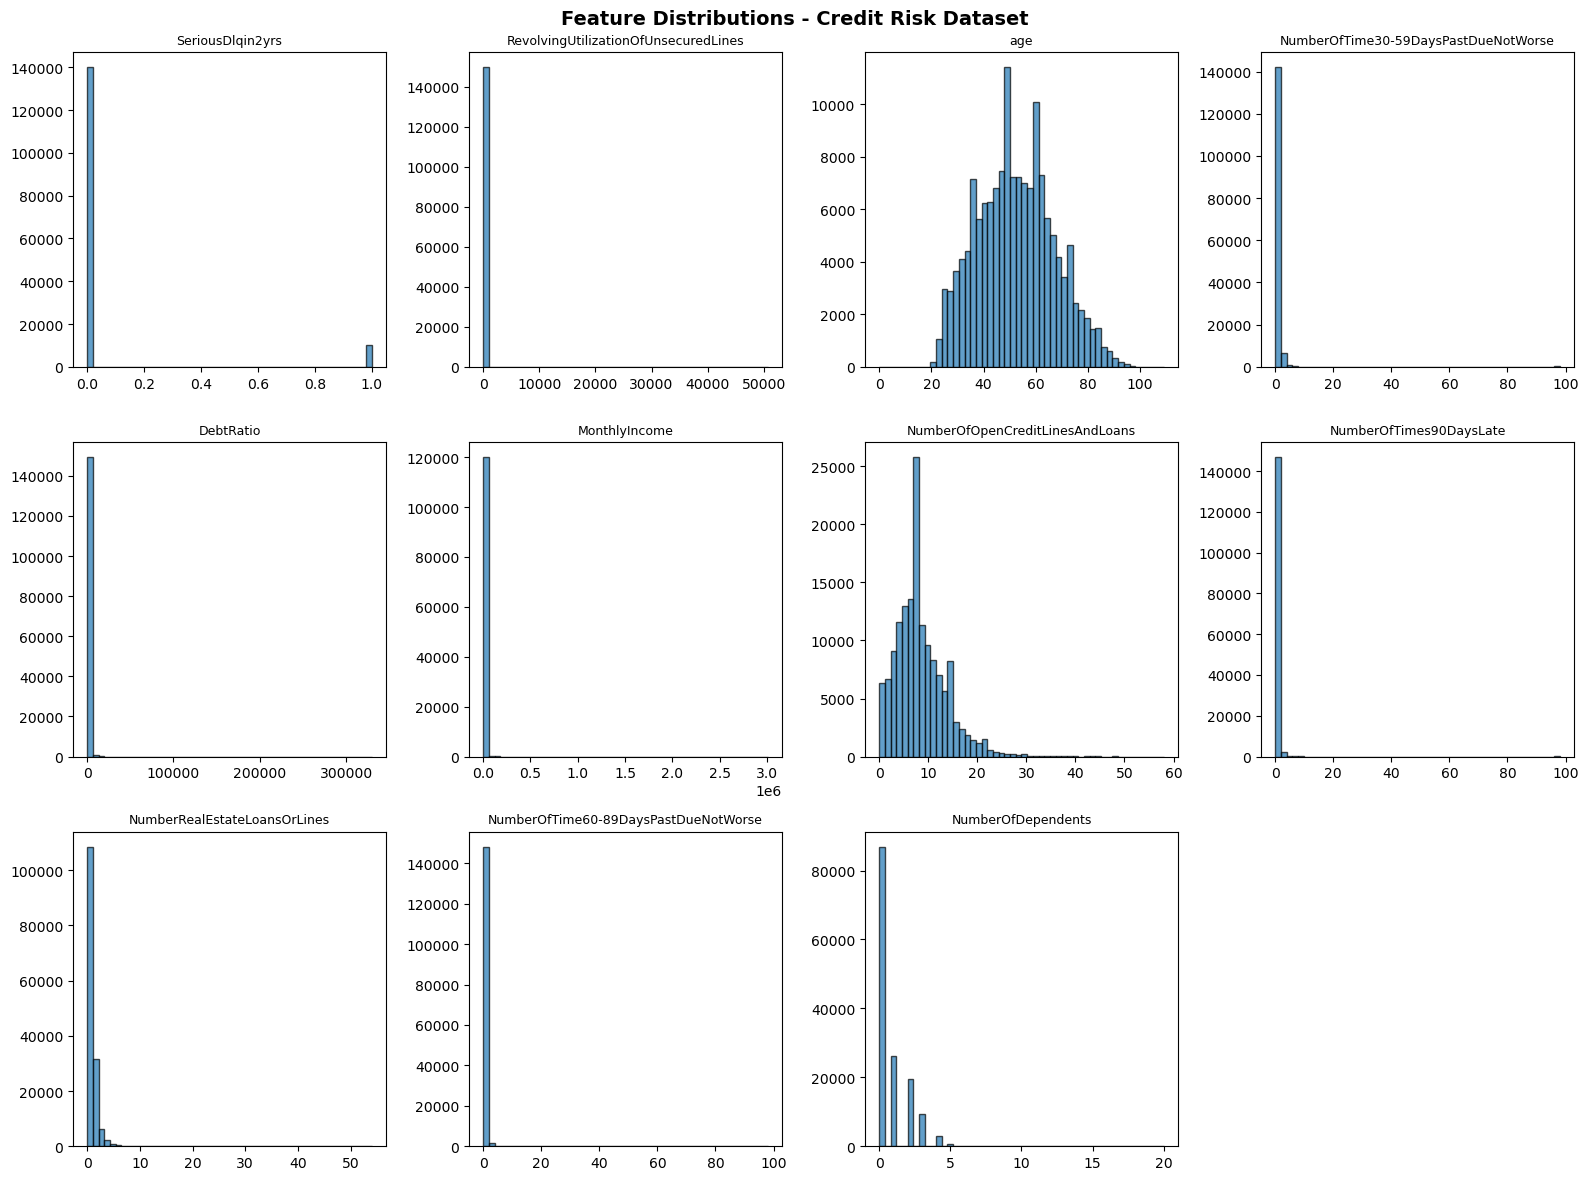

Distribution plot saved


In [3]:
# Visualise distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

columns = df.columns.tolist()

for i, col in enumerate(columns):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions - Credit Risk Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("Distribution plot saved")

=== CORRELATION WITH TARGET ===
SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


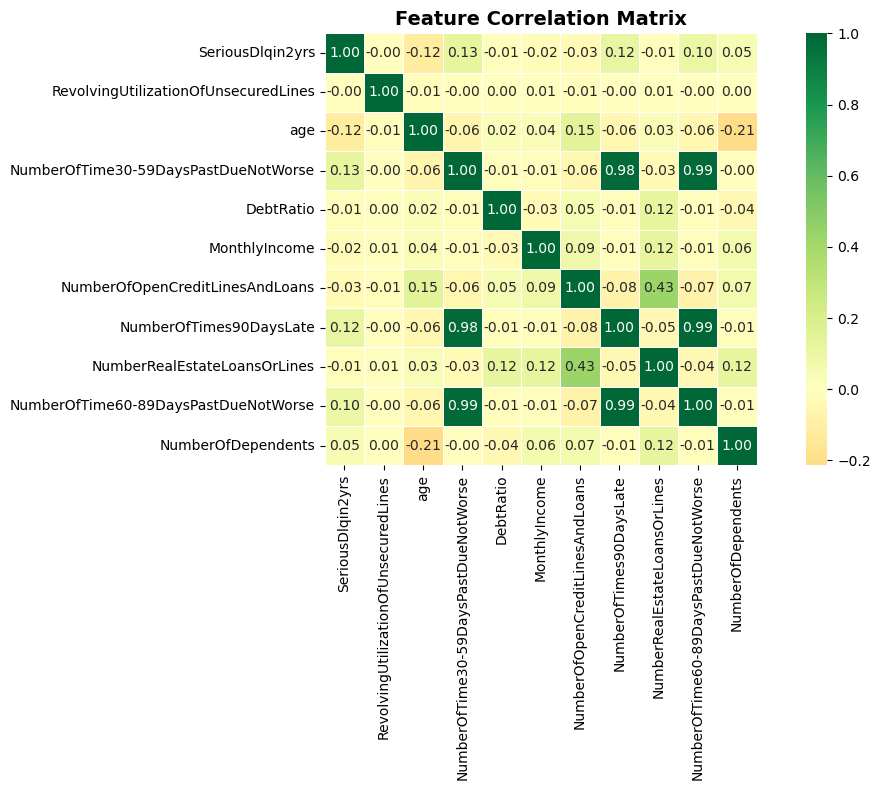

Correlation matrix saved


In [4]:
# Correlation with target
print("=== CORRELATION WITH TARGET ===")
correlations = df.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)
print(correlations)

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("Correlation matrix saved")

In [5]:
# Document data quality issues and cleaning decisions
print("=== DATA CLEANING DECISIONS ===")
print()
print("1. MISSING VALUES:")
print("   - MonthlyIncome (19.82% missing): Impute with median grouped by age bracket")
print("   - NumberOfDependents (2.62% missing): Impute with median (0)")
print()
print("2. OUTLIERS:")
print("   - RevolvingUtilizationOfUnsecuredLines: Cap at 1.0 (it's a ratio)")
print("   - age: Remove rows where age = 0 (invalid)")
print("   - DebtRatio: Cap at 99th percentile")
print("   - MonthlyIncome: Cap at 99th percentile")
print("   - Late payment counts: Cap at 10 (98 is clearly a data entry error)")
print()
print("3. CLASS IMBALANCE:")
print("   - 6.68% default rate")
print("   - Will use scale_pos_weight in LightGBM to handle imbalance")
print("   - Evaluation metric: AUC-ROC (not accuracy - misleading for imbalanced data)")
print()
print("4. FEATURE ENGINEERING:")
print("   - Create total_late_payments = sum of all three late payment features")
print("   - Create debt_to_income = DebtRatio / MonthlyIncome (after imputation)")

# Calculate scale_pos_weight for LightGBM
neg = (df['SeriousDlqin2yrs'] == 0).sum()
pos = (df['SeriousDlqin2yrs'] == 1).sum()
scale_pos_weight = neg / pos
print(f"\n5. scale_pos_weight for LightGBM: {scale_pos_weight:.2f}")

=== DATA CLEANING DECISIONS ===

1. MISSING VALUES:
   - MonthlyIncome (19.82% missing): Impute with median grouped by age bracket
   - NumberOfDependents (2.62% missing): Impute with median (0)

2. OUTLIERS:
   - RevolvingUtilizationOfUnsecuredLines: Cap at 1.0 (it's a ratio)
   - age: Remove rows where age = 0 (invalid)
   - DebtRatio: Cap at 99th percentile
   - MonthlyIncome: Cap at 99th percentile
   - Late payment counts: Cap at 10 (98 is clearly a data entry error)

3. CLASS IMBALANCE:
   - 6.68% default rate
   - Will use scale_pos_weight in LightGBM to handle imbalance
   - Evaluation metric: AUC-ROC (not accuracy - misleading for imbalanced data)

4. FEATURE ENGINEERING:
   - Create total_late_payments = sum of all three late payment features
   - Create debt_to_income = DebtRatio / MonthlyIncome (after imputation)

5. scale_pos_weight for LightGBM: 13.96
